In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print("imported successfully!")

imported successfully!


# Data preparation:

In [4]:
X, y = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


each image is 28x28 = 784 pixels, there are 70000 images

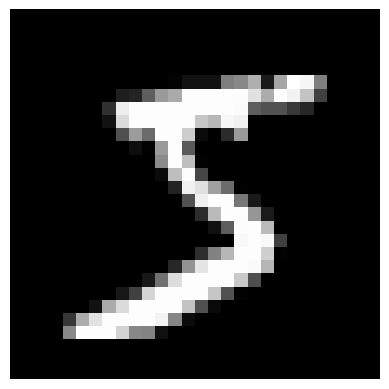

Label: 5


In [5]:
image = X[0].reshape(28, 28)
#looking at a random data
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()
print("Label:", y[0])

In [6]:
#data normalization, using 0-255 for a standard 8-bit grayscale image 
X = X.astype(np.float32) / 255.0
y = y.astype(int)

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [7]:
# defining training and testing data separately
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Training data: (56000, 784)
Test data: (14000, 784)


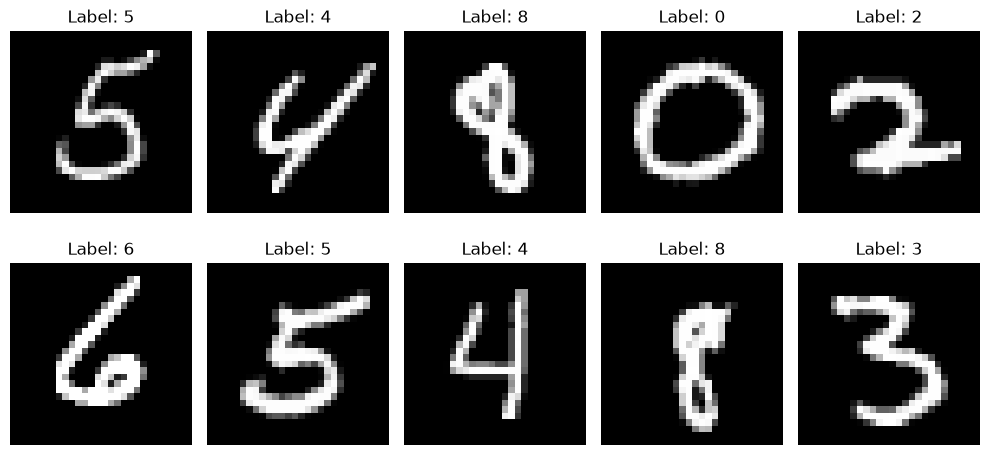

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Neural network:
I will be building a neural network just using numpy, in order to get more familiar with the workings behind popular libraries like Tensorflow, Pytorch and Keras.

In [29]:
def relu(z):
    return np.maximum(0, z)


def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2

    return Z1, A1, Z2

In [30]:
def train(X, y, epochs=20, learning_rate=0.1):

    input_size = 784
    hidden_size = 128
    output_size = 10

    # Initialize parameters
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))

    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))

    m = X.shape[0]

    # One-hot labels
    Y = np.zeros((m, output_size))
    Y[np.arange(m), y] = 1

    for epoch in range(epochs):

        # forward propagation
        Z1 = X @ W1 + b1
        A1 = relu(Z1)

        Z2 = A1 @ W2 + b2
        P = softmax(Z2)

        # loss
        loss = -np.mean(
            np.log(P[np.arange(m), y] + 1e-8)
        )

        # backward propagation
        dZ2 = P - Y

        dW2 = (A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * (Z1 > 0)

        dW1 = (X.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # updating parameters
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        # accuracy
        predictions = np.argmax(P, axis=1)
        accuracy = np.mean(predictions == y)

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"| Loss: {loss:.4f} "
            f"| Accuracy: {accuracy:.4f}"
        )

    return W1, b1, W2, b2

In [31]:
W1, b1, W2, b2 = train(
    X_train,
    y_train,
    epochs=20,
    learning_rate=0.1
)

Epoch 1/20 | Loss: 2.3037 | Accuracy: 0.0436
Epoch 2/20 | Loss: 2.3026 | Accuracy: 0.0720
Epoch 3/20 | Loss: 2.3014 | Accuracy: 0.1136
Epoch 4/20 | Loss: 2.3003 | Accuracy: 0.1527
Epoch 5/20 | Loss: 2.2992 | Accuracy: 0.1902
Epoch 6/20 | Loss: 2.2981 | Accuracy: 0.2294
Epoch 7/20 | Loss: 2.2969 | Accuracy: 0.2669
Epoch 8/20 | Loss: 2.2957 | Accuracy: 0.2993
Epoch 9/20 | Loss: 2.2945 | Accuracy: 0.3272
Epoch 10/20 | Loss: 2.2931 | Accuracy: 0.3503
Epoch 11/20 | Loss: 2.2918 | Accuracy: 0.3708
Epoch 12/20 | Loss: 2.2903 | Accuracy: 0.3884
Epoch 13/20 | Loss: 2.2887 | Accuracy: 0.4034
Epoch 14/20 | Loss: 2.2870 | Accuracy: 0.4170
Epoch 15/20 | Loss: 2.2852 | Accuracy: 0.4278
Epoch 16/20 | Loss: 2.2833 | Accuracy: 0.4364
Epoch 17/20 | Loss: 2.2812 | Accuracy: 0.4438
Epoch 18/20 | Loss: 2.2790 | Accuracy: 0.4493
Epoch 19/20 | Loss: 2.2765 | Accuracy: 0.4534
Epoch 20/20 | Loss: 2.2739 | Accuracy: 0.4563


In [ ]:
Z1, A1, Z2 = forward(
    X_test,
    W1,
    b1,
    W2,
    b2
)

P = softmax(Z2)

predictions = np.argmax(P, axis=1)

test_accuracy = np.mean(predictions == y_test)

print("Test accuracy:", test_accuracy)

input: (1, 784)
hidden: (1, 128)
output: (1, 10)


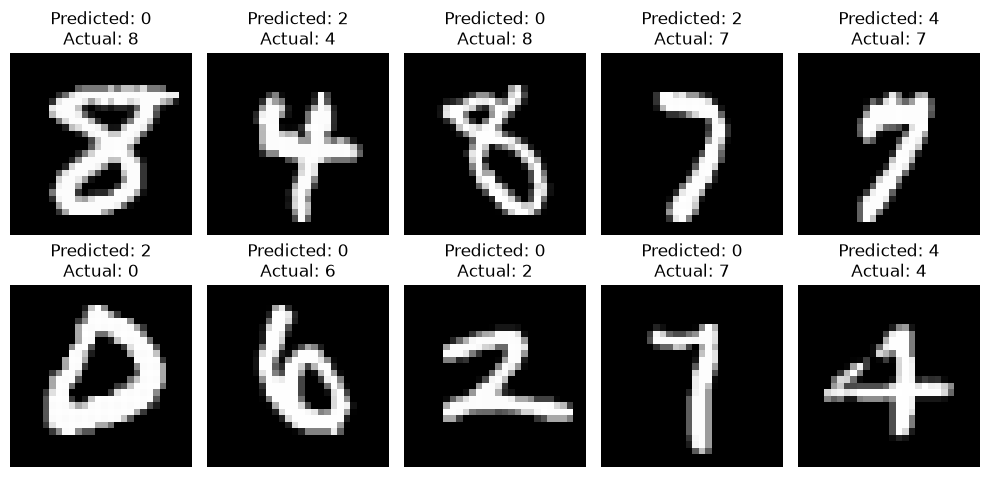

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    
    ax.set_title(
        f"Predicted: {predictions[i]}\nActual: {y_test[i]}"
    )
    
    ax.axis("off")

plt.tight_layout()
plt.show()